# FEEMS: Prepare Inputs — *An. funestus*

**Kernel**: `feems_e`

This notebook:
1. Queries Af1 for samples in the study region
2. Creates an outer boundary polygon from Natural Earth land data
3. Clips the FEEMS grid (`grid_<RESOLUTION>.shp`) to the study region and plots the bounding box, outer boundary, grid, and sample locations
4. Exports biallelic SNPs to PLINK format via `af1.biallelic_snps_to_plink()`

All outputs saved to `feems_outputs/`.

In [1]:
# Imports
import numpy as np
import pandas as pd
from importlib.resources import files as _res_files

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

from shapely.geometry import box as shapely_box
from shapely.ops import unary_union, transform
import pyproj

import malariagen_data
from feems.utils import prepare_graph_inputs

import os

## 0. User config - adjust params accordingly

In [2]:
import os

# ── USER CONFIG ────────────────────────────────────────────────────────────
study_taxon  = 'funestus'         # taxon field in AF1 metadata
study_region = 'Kenya'            # single country string, or list e.g. ['Kenya', 'Tanzania']
study_prefix = 'funestus-kenya'   # used for file names and plot titles

bbox = dict(xmin=33.5, xmax=42.0, ymin=-5.0, ymax=5.0)

sample_sets = None   # None = all public sets; e.g. ['1232-VO-KE-OCHOMO-VMF00044']

# query is built automatically; override manually if you need something custom
if isinstance(study_region, list):
    sample_query = f'taxon == "{study_taxon}" & country in {study_region}'
else:
    sample_query = f'taxon == "{study_taxon}" & country == "{study_region}"'

snp_region     = '3RL:6000000-9000000'
n_snps         = 100_000
min_minor_ac   = 2
max_missing_an = 1

grid_res_km    = 50   # 100 or 500 use FEEMS built-in grids; anything else generates a custom grid
land_buffer_km = 20

outdir  = 'feems_outputs'
shp_dir = f'{outdir}/shapefiles'
plk_dir = f'{outdir}/plink'
for d in [outdir, shp_dir, plk_dir]:
    os.makedirs(d, exist_ok=True)
# ──────────────────────────────────────────────────────────────────────────

## 1. Query AF1 sample metadata
Change this (e.g. to Ag3 or As1) if you need to switch between data releases for different species complexes

In [3]:
release = malariagen_data.Af1(pre=True, check_location=False) #change this to Ag3/As1 etc

# View all available sample sets — pick the Kenya ones
release.sample_sets()

,sample_set,sample_count,study_id,study_url,terms_of_use_expiry_date,terms_of_use_url,release,unrestricted_use
0,1229-VO-GH-DADZIE-VMF00095,36,1229-VO-GH-DADZIE,https://www.malariagen.net/partner_study/1229-...,2026-04-29,https://malariagen.github.io/vector-data/af1/a...,1.0,True
1,1230-VO-GA-CF-AYALA-VMF00045,50,1230-VO-MULTI-AYALA,https://www.malariagen.net/partner_study/1230-...,2026-04-29,https://malariagen.github.io/vector-data/af1/a...,1.0,True
2,1231-VO-MULTI-WONDJI-VMF00043,320,1231-VO-MULTI-WONDJI,https://www.malariagen.net/partner_study/1231-...,2026-04-29,https://malariagen.github.io/vector-data/af1/a...,1.0,True
3,1232-VO-KE-OCHOMO-VMF00044,81,1232-VO-KE-OCHOMO,https://www.malariagen.net/partner_study/1232-...,2026-04-29,https://malariagen.github.io/vector-data/af1/a...,1.0,True
4,1235-VO-MZ-PAAIJMANS-VMF00094,76,1235-VO-MZ-PAAIJMANS,https://www.malariagen.net/partner_study/1235-...,2026-04-29,https://malariagen.github.io/vector-data/af1/a...,1.0,True
5,1236-VO-TZ-OKUMU-VMF00090,10,1236-VO-TZ-OKUMU,https://www.malariagen.net/partner_study/1236-...,2026-04-29,https://malariagen.github.io/vector-data/af1/a...,1.0,True
6,1240-VO-CD-KOEKEMOER-VMF00099,43,1240-VO-MULTI-KOEKEMOER,https://www.malariagen.net/partner_study/1240-...,2026-04-29,https://malariagen.github.io/vector-data/af1/a...,1.0,True
7,1240-VO-MZ-KOEKEMOER-VMF00101,40,1240-VO-MULTI-KOEKEMOER,https://www.malariagen.net/partner_study/1240-...,2026-04-29,https://malariagen.github.io/vector-data/af1/a...,1.0,True
8,1178-VO-UG-LAWNICZAK-VMF00025,7,1178-VO-UG-LAWNICZAK,https://www.malariagen.net/partner_study/1178-...,2026-04-29,https://malariagen.github.io/vector-data/af1/a...,1.1,True
9,1190-VO-GH-AMENGA-ETEGO-VMF00013,1,1190-VO-GH-AMENGA-ETEGO,https://www.malariagen.net/partner_study/1190-...,2026-04-29,https://malariagen.github.io/vector-data/af1/a...,1.1,True


In [4]:
df_samples = release.sample_metadata(
    sample_query=sample_query,
    sample_sets=sample_sets,
)
print(f'Found {len(df_samples)} samples matching: {sample_query!r}')
df_samples[['sample_id', 'country', 'location', 'latitude', 'longitude']].head(10)

Found 573 samples matching: 'taxon == "funestus" & country == "Kenya"'


,sample_id,country,location,latitude,longitude
0,VBS10154-4954STDY7089682,Kenya,Nyawiya,-0.466,34.319
1,VBS17631,Kenya,Ahero,-0.174,34.920
2,VBS17632,Kenya,Ahero,-0.174,34.920
3,VBS17633,Kenya,Ahero,-0.174,34.920
4,VBS17634,Kenya,Ahero,-0.174,34.920
5,VBS17635,Kenya,Ahero,-0.174,34.920
6,VBS17636,Kenya,Ahero,-0.174,34.920
7,VBS17637,Kenya,Ahero,-0.174,34.920
8,VBS17638,Kenya,Ahero,-0.174,34.920
9,VBS17641,Kenya,Ahero,-0.174,34.920


In [5]:
n_before = len(df_samples)
df_samples = df_samples.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)
if len(df_samples) < n_before:
    print(f'Dropped {n_before - len(df_samples)} samples with missing coordinates')

coord = df_samples[['longitude', 'latitude']].to_numpy()
print(f'{len(coord)} samples — lon [{coord[:,0].min():.2f}, {coord[:,0].max():.2f}]  '
      f'lat [{coord[:,1].min():.2f}, {coord[:,1].max():.2f}]')

coords_path = f'{outdir}/sample_coords_{study_prefix}.csv'
df_samples[['sample_id', 'longitude', 'latitude']].to_csv(coords_path, index=False)
print(f'Saved sample coordinates → {coords_path}')

573 samples — lon [34.18, 39.91]  lat [-3.51, 0.98]
Saved sample coordinates → feems_outputs/sample_coords_funestus-kenya.csv


## 2. Create outer boundary polygon

The outer boundary defines the landscape FEEMS optimises over. We buffer the
Natural Earth 10m land outline within the bounding box by `LAND_BUFFER_KM` km,
then take its convex hull to get a single clean polygon.

In [6]:
def geodetic_buffer_km(geom_wgs84, km):
    lon0, lat0 = geom_wgs84.centroid.x, geom_wgs84.centroid.y
    aeqd = pyproj.Proj(proj='aeqd', lat_0=lat0, lon_0=lon0, datum='WGS84', units='m')
    wgs  = pyproj.Proj(proj='latlong', datum='WGS84')
    fwd  = pyproj.Transformer.from_proj(wgs, aeqd, always_xy=True).transform
    inv  = pyproj.Transformer.from_proj(aeqd, wgs, always_xy=True).transform
    return transform(inv, transform(fwd, geom_wgs84).buffer(km * 1000))

bbox_geom = shapely_box(bbox['xmin'], bbox['ymin'], bbox['xmax'], bbox['ymax'])

coast_shp = shpreader.natural_earth(resolution='10m', category='physical', name='land')
land_polys = []
for geom in shpreader.Reader(coast_shp).geometries():
    g = geom.intersection(bbox_geom)
    if not g.is_empty:
        land_polys.append(g)
land = unary_union(land_polys)

outer_geom   = geodetic_buffer_km(land, land_buffer_km).intersection(bbox_geom)
outer_coords = np.array(outer_geom.convex_hull.exterior.coords)

outer_path = f'{shp_dir}/outer_{study_prefix}.csv'
np.savetxt(outer_path, outer_coords, delimiter=',', fmt='%.6f', header='lon,lat', comments='')
print(f'Outer boundary: {len(outer_coords)} vertices → {outer_path}')

Outer boundary: 6 vertices → feems_outputs/shapefiles/outer_funestus-kenya.csv


## 3. Build FEEMS grid and clip to study region

If `GRID_RESOLUTION_KM` is 100 or 500 the FEEMS built-in global grid is used.
Any other value generates a custom triangular grid at that spacing (saved to
`feems_outputs/shapefiles/`) by laying down a hexagonal lattice of points and
computing a Delaunay triangulation. `prepare_graph_inputs` then clips the grid
to the outer boundary and returns the node coordinates and edges.

It is actually easier to do this in R using ddgridr but for the sake of keeping everything in Python, Claude has given me this solution.

In [7]:
import fiona
from pyproj import CRS as ProjCRS
from scipy.spatial import Delaunay
from shapely.geometry import mapping, Polygon as ShapelyPolygon


def make_feems_grid(bbox, resolution_km, output_shp):
    lat_c = (bbox['ymin'] + bbox['ymax']) / 2
    d_lon = resolution_km / (111.0 * np.cos(np.radians(lat_c)))
    d_lat = resolution_km / 111.0
    row_dy = d_lat * np.sqrt(3) / 2
    pts_list = []
    ys = np.arange(bbox['ymin'] - 2 * row_dy, bbox['ymax'] + 2 * row_dy, row_dy)
    for iy, y in enumerate(ys):
        x_off = d_lon / 2 if iy % 2 else 0.0
        xs = np.arange(bbox['xmin'] - 2 * d_lon + x_off, bbox['xmax'] + 2 * d_lon, d_lon)
        for x in xs:
            pts_list.append((round(float(x), 5), round(float(y), 5)))
    pts = np.array(pts_list)
    tri = Delaunay(pts)
    max_edge_deg = 2 * max(d_lon, d_lat)
    schema = {'geometry': 'Polygon', 'properties': {}}
    n_written = 0
    with fiona.open(output_shp, 'w', driver='ESRI Shapefile',
                    crs=ProjCRS.from_epsg(4326), schema=schema) as dst:
        for simplex in tri.simplices:
            v = pts[simplex]
            edge_lens = [np.linalg.norm(v[i] - v[(i + 1) % 3]) for i in range(3)]
            if max(edge_lens) > max_edge_deg:
                continue
            ring = v.tolist() + [v[0].tolist()]
            poly = ShapelyPolygon(ring)
            if poly.is_valid and not poly.is_empty:
                dst.write({'geometry': mapping(poly), 'properties': {}})
                n_written += 1
    print(f'Grid ({resolution_km} km): {len(pts)} lattice pts, {n_written} triangles → {output_shp}')
    return output_shp


if grid_res_km == 100:
    grid_path = str(_res_files('feems').joinpath('data/grid_100.shp'))
    print('Using FEEMS built-in 100 km grid')
elif grid_res_km == 500:
    grid_path = str(_res_files('feems').joinpath('data/grid_500.shp'))
    print('Using FEEMS built-in 500 km grid')
else:
    grid_path = f'{shp_dir}/feems_grid_{grid_res_km}km.shp'
    if not os.path.exists(grid_path):
        make_feems_grid(bbox, grid_res_km, grid_path)
    else:
        print(f'Using cached grid: {grid_path}')

outer_prep, edges, grid, _ = prepare_graph_inputs(
    coord=coord, ggrid=grid_path, translated=False, buffer=0, outer=outer_coords,
)
print(f'Grid nodes: {len(grid)},  edges: {len(edges)}')

Using cached grid: feems_outputs/shapefiles/feems_grid_50km.shp
Grid nodes: 474,  edges: 1337


## 4. Visualise: bounding box · outer boundary · grid · samples

Left panel — study region overview.  
Right panel — FEEMS graph nodes and edges (what the model will see).

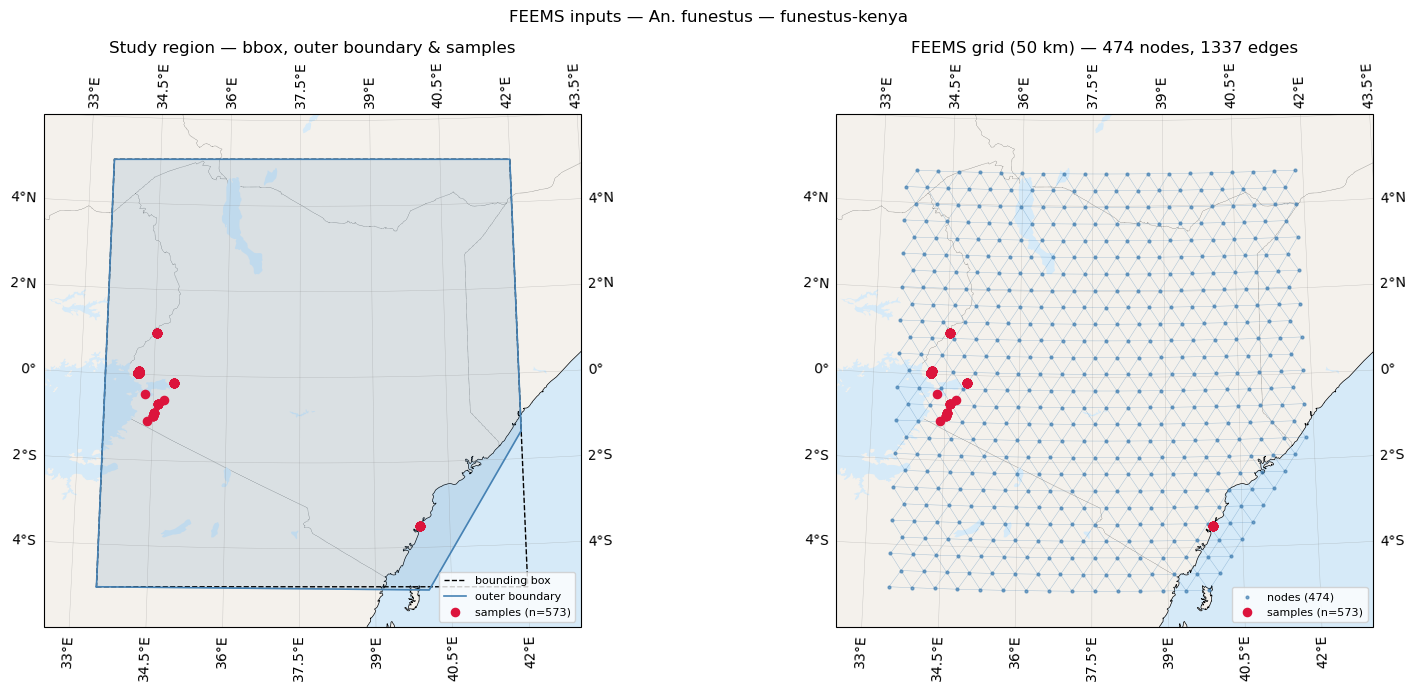

Saved at feems_outputs/feems_inputs_funestus-kenya.png


In [8]:
lon_c = (bbox['xmin'] + bbox['xmax']) / 2
lat_c = (bbox['ymin'] + bbox['ymax']) / 2
proj  = ccrs.EquidistantConic(central_longitude=lon_c, central_latitude=lat_c)
ext   = [bbox['xmin'] - 1, bbox['xmax'] + 1, bbox['ymin'] - 1, bbox['ymax'] + 1]

def base_map(ax, extent=ext):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      facecolor='#f4f1ec', zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor='#d6eaf8', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=1)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=':', zorder=1)
    ax.add_feature(cfeature.LAKES,     facecolor='#d6eaf8', zorder=1)
    ax.gridlines(draw_labels=True, linewidth=0.3, color='grey', alpha=0.4)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={'projection': proj})

# left: bbox + outer boundary + samples
base_map(ax0)
ax0.set_title('Study region — bbox, outer boundary & samples')
bbox_xs = [bbox['xmin'], bbox['xmax'], bbox['xmax'], bbox['xmin'], bbox['xmin']]
bbox_ys = [bbox['ymin'], bbox['ymin'], bbox['ymax'], bbox['ymax'], bbox['ymin']]
ax0.plot(bbox_xs, bbox_ys, transform=ccrs.PlateCarree(), c='k', lw=1, ls='--', label='bounding box')
ax0.fill(outer_coords[:, 0], outer_coords[:, 1], transform=ccrs.PlateCarree(), color='steelblue', alpha=0.15)
ax0.plot(outer_coords[:, 0], outer_coords[:, 1], transform=ccrs.PlateCarree(), c='steelblue', lw=1.2, label='outer boundary')
ax0.scatter(coord[:, 0], coord[:, 1], transform=ccrs.PlateCarree(), s=35, c='crimson', zorder=5, label=f'samples (n={len(coord)})')
ax0.legend(fontsize=8, loc='lower right')

# right: grid edges + nodes + samples
base_map(ax1)
ax1.set_title(f'FEEMS grid ({grid_res_km} km) — {len(grid)} nodes, {len(edges)} edges')
ex = np.empty(len(edges) * 3)
ey = np.empty(len(edges) * 3)
for k, (i, j) in enumerate(edges):
    ex[k*3],   ey[k*3]   = grid[i - 1, 0], grid[i - 1, 1]
    ex[k*3+1], ey[k*3+1] = grid[j - 1, 0], grid[j - 1, 1]
    ex[k*3+2], ey[k*3+2] = np.nan, np.nan
ax1.plot(ex, ey, transform=ccrs.PlateCarree(), color='steelblue', lw=0.3, alpha=0.5, zorder=2)
ax1.scatter(grid[:, 0], grid[:, 1], transform=ccrs.PlateCarree(), s=4, c='steelblue', alpha=0.7, zorder=3, label=f'nodes ({len(grid)})')
ax1.scatter(coord[:, 0], coord[:, 1], transform=ccrs.PlateCarree(), s=35, c='crimson', zorder=5, label=f'samples (n={len(coord)})')
ax1.legend(fontsize=8, loc='lower right')

plt.suptitle(f'FEEMS inputs — An. {study_taxon} — {study_prefix}', fontsize=12)
plt.tight_layout()
fig_path = f'{outdir}/feems_inputs_{study_prefix}.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved at {fig_path}')

## 5. Export SNPs to PLINK

This step queries AF1 and writes BED/BIM/FAM files. It can take **several minutes**.

The output prefix will be printed at the end of this cell — copy it into `PLINK_PREFIX` in `run_feems.ipynb`.

In [10]:
release.biallelic_snps_to_plink(
    region=snp_region,
    n_snps=n_snps,
    sample_query=sample_query,
    sample_sets=sample_sets,
    output_dir=plk_dir,
    min_minor_ac=min_minor_ac,
    max_missing_an=max_missing_an,
)

import glob
bed_files = sorted(glob.glob(f'{plk_dir}/*.bed'))
print('\nGenerated PLINK files:')
for f in bed_files:
    print(f'  {f[:-4]}')


Generated PLINK files:
  feems_outputs/plink/3RL:6000000-9000000.100000.2.1.0
